# Delta-Hedging and Model Risk

The main idea behind this project was extending what I learnt in Options 101 by Akuna Capital and build an intuition for how options behave. 

This notebook builds a Black-Scholes delta-hedging simulator from the ground up, validates it two independent ways, then spends the rest of its length trying to break it via discretization error, transaction costs, jumps, stochastic vol, and a real SPY-calibrated tail-risk number at the end. 

Summary:
1. A BS pricing engine with closed form Greeks (validated through finite differences and PCP). Discrete hedging engine and replication error.
2. Gamma-Theta PnL identity, verified against full repricing.
3. PnL Decomposition into convexity and theta-decay.
4. Cost-aware hedges exploring the cost-risk frontier, optimal rebalance frequency, band hedge and a Leland Vol adjust. 
5. Model risk assessment (Merton dynamics jumps, vega leak under Heston and drift invariance)
6. Callibrating jump-diffusion model to real SPY data
7. Risk report on mean, vol, VaR, CVar of the hedged PnL.

## 0. Setup

### 0.1 Dependencies

In [ ]:
# %pip install -q numpy scipy matplotlib pandas yfinance

### 0.2 Imports

Standard scientific stack. Warnings are suppressed globally mostly to silence `yfinance`'s noisier deprecation warnings

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, skew
import warnings
warnings.filterwarnings("ignore")

### 0.3 Plot style (dark mode)


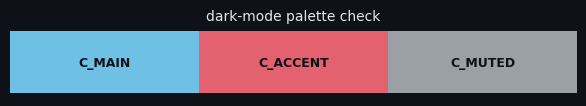

In [5]:
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (12, 5.5), "font.size": 11, "axes.titlesize": 12,
    "axes.labelsize": 11, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "#0E1117", "axes.facecolor": "#0E1117",
    "savefig.facecolor": "#0E1117",
    "grid.color": "#2A2E36", "grid.alpha": 0.4,
    "text.color": "#E6E6E6", "axes.labelcolor": "#E6E6E6",
    "xtick.color": "#E6E6E6", "ytick.color": "#E6E6E6",
})
C_MAIN, C_ACCENT, C_MUTED = "#6EC1E4", "#E4626F", "#9AA0A6"

fig, ax = plt.subplots(figsize=(6, 1.2))
for i, (name, c) in enumerate([("C_MAIN", C_MAIN), ("C_ACCENT", C_ACCENT), ("C_MUTED", C_MUTED)]):
    ax.barh(0, 1, left=i, color=c)
    ax.text(i + 0.5, 0, name, ha="center", va="center", fontsize=9, color="#0E1117", fontweight="bold")
ax.set_xlim(0, 3); ax.axis("off")
ax.set_title("dark-mode palette check", fontsize=10)
plt.tight_layout(); plt.show()

### 0.4 A running example

Simple values for a standard european call

In [6]:
S0, K, T, R, SIGMA = 100.0, 100.0, 1.0, 0.02, 0.20

print("Environment configured.")
print(f"Running example: S0={S0:.0f}, K={K:.0f}, T={T:.0f}y, r={R:.0%}, sigma={SIGMA:.0%}")

Environment configured.
Running example: S0=100, K=100, T=1y, r=2%, sigma=20%


# 1. Theoretical Foundation

## 1.1 Black–Scholes framework and replication

Assume the underlying asset follows geometric Brownian motion under the physical measure,

$$
dS_t=\mu S_t\,dt+\sigma S_t\,dW_t,
$$

and let \(V(S,t)\) denote the value of a European call with strike \(K\) and maturity \(T\). Applying Itô's lemma gives

$$
dV=\left(\partial_tV+\mu S\,\partial_SV+\frac12\sigma^2S^2\partial_{SS}V\right)dt
+\sigma S\,\partial_SV\,dW.
$$

Construct the self-financing portfolio

$$
\Pi=V-\Delta S,
$$

consisting of a long option and a short position of \(\Delta\) shares. Choosing

$$
\Delta=\partial_SV
$$

eliminates the stochastic term, producing

$$
d\Pi
=dV-\Delta\,dS
=\left(\partial_tV+\frac12\sigma^2S^2\partial_{SS}V\right)dt.
$$

The resulting portfolio is locally riskless. Consequently, no-arbitrage requires it to earn the risk-free rate,

$$
d\Pi=r(V-\Delta S)\,dt,
$$

which yields the Black–Scholes partial differential equation,

$$
\partial_tV
+\frac12\sigma^2S^2\partial_{SS}V
+rS\partial_SV
-rV=0,
$$

with terminal condition

$$
V(S,T)=\max(S-K,0).
$$

The corresponding European call price is

$$
C=S\,N(d_1)-Ke^{-rT}N(d_2),
$$

where

$$
d_1=\frac{\ln(S/K)+(r+\sigma^2/2)T}{\sigma\sqrt{T}},
\qquad
d_2=d_1-\sigma\sqrt{T},
$$

and the principal Greeks are

$$
\Delta=N(d_1),
$$

$$
\Gamma=\frac{N'(d_1)}{S\sigma\sqrt{T}},
$$

$$
\Theta
=
-\frac{SN'(d_1)\sigma}{2\sqrt{T}}
-rKe^{-rT}N(d_2),
$$

$$
\mathcal{V}
=
SN'(d_1)\sqrt{T}.
$$

The key implication is that **once the option is delta hedged, the physical drift \(\mu\) disappears entirely from the portfolio dynamics.** Option valuation therefore depends only on volatility and the risk-free rate, rather than investors' expectations of future returns.

---

## 1.2 One-step delta-hedging P\&L

Consider a single rebalancing interval \([t,t+\delta t]\), during which the hedge is held fixed at

$$
\Delta=\partial_SV(S,t).
$$

The portfolio consists of the option, the frozen stock hedge, and a cash account

$$
B=-V+\Delta S,
$$

earning the continuously compounded rate \(r\). The incremental profit and loss is

$$
\text{P\&L}
=
\delta V
-\Delta\,\delta S
+r(\Delta S-V)\delta t.
$$

Expanding the option value to second order,

$$
\delta V
=
\Theta\,\delta t
+\Delta\,\delta S
+\frac12\Gamma\,\delta S^2
+O(\delta t^{3/2}),
$$

and substituting the Black–Scholes PDE identity,

$$
\Theta
=
rV-rS\Delta-\frac12\sigma^2S^2\Gamma,
$$

gives

$$
\text{P\&L}
=
\left(
rV-rS\Delta-\frac12\sigma^2S^2\Gamma
\right)\delta t
+\frac12\Gamma\,\delta S^2
+r(\Delta S-V)\delta t
+O(\delta t^{3/2}).
$$

The financing terms cancel exactly, leaving

$$
\boxed{
\text{P\&L}
=
\frac12\Gamma
\left(
\delta S^2-\sigma^2S^2\delta t
\right)
+O(\delta t^{3/2})
}
$$

or, equivalently,

$$
\boxed{
\text{P\&L}
=
\frac12\Gamma S^2
\left[
\left(\frac{\delta S}{S}\right)^2
-\sigma^2\delta t
\right]
+O(\delta t^{3/2}).
}
$$

This identity underpins the economics of delta hedging. A delta-hedged long option profits whenever **realized variance exceeds implied variance**, and loses when realized variance falls short. Gamma determines the sensitivity of this payoff, while theta represents the corresponding financing cost. The breakeven move satisfies

$$
|\delta S|
=
\sigma S\sqrt{\delta t},
$$

which is approximately **1.26% per trading day** for an annual volatility of \(20\%\).

The remainder of this notebook explores how this idealized result changes once practical frictions are introduced, including discrete hedge rebalancing, transaction costs, stochastic volatility, and jump dynamics.

Throughout, we use a single reference contract: a one-year at-the-money European call with

$$
S_0=K=100,\qquad
r=2\%,\qquad
\sigma=20\%,
$$

held long and delta hedged throughout its life.

In [7]:
def bs_price(S, K, T, r, sig):
    """Black-Scholes price of a European call."""
    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
    d2 = d1 - sig * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_delta(S, K, T, r, sig):
    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
    return norm.cdf(d1)

def bs_gamma(S, K, T, r, sig):
    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
    return norm.pdf(d1) / (S * sig * np.sqrt(T))

def bs_theta(S, K, T, r, sig):
    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
    d2 = d1 - sig * np.sqrt(T)
    return -(S * norm.pdf(d1) * sig) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)

def bs_vega(S, K, T, r, sig):
    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

### 1.2 Validation 1 — finite differences

**Intuition.** The Greeks are derivatives of the price formula. If a closed-form Greek and a numerically differentiated price agree to several decimal places, the algebra in `bs_delta`/`bs_gamma`/`bs_theta`/`bs_vega` is correct — this catches sign errors, misplaced factors, and wrong-variable differentiation, the most common ways a from-scratch Black-Scholes implementation breaks.

**Mathematical formulation.** Central differences:

$$\Delta \approx \frac{C(S+h)-C(S-h)}{2h}, \qquad \Gamma \approx \frac{C(S+h)-2C(S)+C(S-h)}{h^2}$$

and analogous central differences in $T$ for theta (with a sign flip, since theta is defined as $-\partial C/\partial T$) and in $\sigma$ for vega.

**Implementation.** `h = 1e-4` — small enough for accuracy, large enough to avoid floating-point cancellation in the second difference for gamma. Every Greek gets checked against its finite-difference counterpart in one table, then asserted against a tolerance so a broken Greek fails loudly instead of quietly.

In [8]:
h = 1e-4
fd_delta = (bs_price(S0 + h, K, T, R, SIGMA) - bs_price(S0 - h, K, T, R, SIGMA)) / (2 * h)
fd_gamma = (bs_price(S0 + h, K, T, R, SIGMA) - 2 * bs_price(S0, K, T, R, SIGMA)
            + bs_price(S0 - h, K, T, R, SIGMA)) / h**2
fd_theta = -(bs_price(S0, K, T + h, R, SIGMA) - bs_price(S0, K, T - h, R, SIGMA)) / (2 * h)
fd_vega = (bs_price(S0, K, T, R, SIGMA + h) - bs_price(S0, K, T, R, SIGMA - h)) / (2 * h)

rows = [
    ("price", bs_price(S0, K, T, R, SIGMA), np.nan),
    ("delta", bs_delta(S0, K, T, R, SIGMA), fd_delta),
    ("gamma", bs_gamma(S0, K, T, R, SIGMA), fd_gamma),
    ("theta (per yr)", bs_theta(S0, K, T, R, SIGMA), fd_theta),
    ("vega (per unit)", bs_vega(S0, K, T, R, SIGMA), fd_vega),
]
print(f"{'quantity':16s} {'analytic':>12s} {'finite diff':>12s} {'abs error':>10s}")
for name, an, fd in rows:
    err = "" if np.isnan(fd) else f"{abs(an - fd):10.2e}"
    fd_s = "" if np.isnan(fd) else f"{fd:12.6f}"
    print(f"{name:16s} {an:12.6f} {fd_s:>12s} {err:>10s}")

assert abs(bs_delta(S0, K, T, R, SIGMA) - fd_delta) < 1e-6, "delta mismatch"
assert abs(bs_gamma(S0, K, T, R, SIGMA) - fd_gamma) < 1e-4, "gamma mismatch"
assert abs(bs_theta(S0, K, T, R, SIGMA) - fd_theta) < 1e-4, "theta mismatch"
assert abs(bs_vega(S0, K, T, R, SIGMA) - fd_vega) < 1e-4, "vega mismatch"
print("\nsanity check: all analytic Greeks match finite differences within tolerance. PASS")

quantity             analytic  finite diff  abs error
price                8.916037                        
delta                0.579260     0.579260   1.35e-11
gamma                0.019552     0.019551   8.41e-07
theta (per yr)      -4.890626    -4.890626   4.98e-09
vega (per unit)     39.104269    39.104269   6.52e-08

sanity check: all analytic Greeks match finite differences within tolerance. PASS


### 1.3 Reading the table

Every Greek should land within `1e-4` to `1e-6` of its finite-difference twin — anything looser than that means a bug, not numerical noise. The asserts above throw before you get to read a wrong number, which is the point of putting a sanity check right after a validation step instead of trusting the printout by eye.

### 1.4 Validation 2 — put-call parity

**Intuition.** Put-call parity is model-free: it holds under any arbitrage-free pricing model, not just Black-Scholes, because it follows from a static replication argument (a call minus a put replicates a forward). If the call price from `bs_price` violates parity, the bug is in the pricing formula itself, independent of anything the Greeks check.

**Mathematical formulation.**

$$C - P = S - Ke^{-rT} \quad\Longrightarrow\quad P = C - S + Ke^{-rT}$$

**Implementation.** One line. The only thing worth checking is that the resulting put price is positive — a negative number here would mean the call price sits below intrinsic-adjusted bounds, a red flag regardless of parity.

In [9]:
call = bs_price(S0, K, T, R, SIGMA)
put_parity = call - S0 + K * np.exp(-R * T)
print(f"put via parity C - S + K e^(-rT) = {put_parity:.6f}  (positive, as required)")

assert put_parity > 0, "parity-implied put price is negative — pricing formula is broken"
print("sanity check: parity-implied put price is positive. PASS")

put via parity C - S + K e^(-rT) = 6.935905  (positive, as required)
sanity check: parity-implied put price is positive. PASS


### 1.5 Reading parity

A positive parity-implied put with no other checks needed is the expected, boring outcome — boring is the goal for a validation cell. Both checks above now agree independently: the pricer is correct, and the Greeks are correct derivatives of it. Everything from here on trusts these five functions without re-deriving them.

## 2. The Gamma-Theta Identity — a Different Running Example

**A note before the math:** this section switches to `t_rem = 0.5` years to maturity and a one-trading-day horizon (`dt_day = 1/252`), instead of the `T = 1` year used everywhere else. That's intentional in the original script — it isolates a generic point mid-life of an option rather than inception — but it's easy to misread as a typo if it's not called out, so: called out.

**Intuition.** Over one day, a delta-hedged option's P&L is dominated by two effects that nearly cancel: convexity gain from the stock having moved (positive, since gamma is positive for a long call) and time decay from one fewer day to expiry (negative, since theta is negative for a long call). The gamma-theta identity is the second-order Taylor expansion of the option value in the stock move, evaluated under the assumption that realized variance over the day matches the model's assumed variance.

**Mathematical formulation.** For a delta-hedged position, one-day P&L is approximately

$$\text{P\&L} \approx \tfrac{1}{2}\Gamma\left(\delta S^2 - \sigma^2 S^2\, \delta t\right)$$

The breakeven move — the stock move at which convexity gain exactly offsets expected decay — is $\delta S^{*} = \sigma S\sqrt{\delta t}$: exactly one day's worth of the model's own volatility.

**Implementation.** Compute the *actual* hedged P&L by full repricing (no approximation) across a grid of dollar moves, then overlay the second-order identity. The gap between the two curves is the higher-order error the identity doesn't capture — small for small moves, growing for large ones.

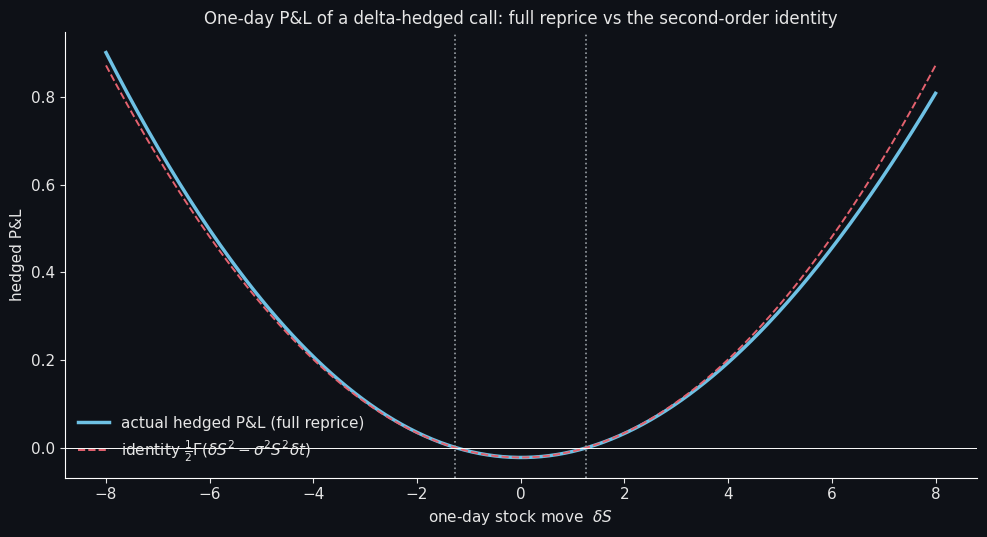

breakeven move: +/- 1.260  (1.26% of spot)
max |actual - identity|, |dS| <= 4 (a 3-sigma day): 0.00723
max |actual - identity| over the full +/-8 range:   0.06372


In [10]:
t_rem, dt_day = 0.5, 1 / 252
V0_ = bs_price(S0, K, t_rem, R, SIGMA)
delta_ = bs_delta(S0, K, t_rem, R, SIGMA)
gamma_ = bs_gamma(S0, K, t_rem, R, SIGMA)

moves = np.linspace(-8, 8, 321)
actual = np.array([
    (bs_price(S0 + dS, K, t_rem - dt_day, R, SIGMA) - V0_)
    - delta_ * dS + R * (delta_ * S0 - V0_) * dt_day
    for dS in moves
])
identity = 0.5 * gamma_ * (moves**2 - SIGMA**2 * S0**2 * dt_day)
breakeven = SIGMA * S0 * np.sqrt(dt_day)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(moves, actual, lw=2.5, color=C_MAIN, label="actual hedged P&L (full reprice)")
ax.plot(moves, identity, lw=1.4, ls="--", color=C_ACCENT,
        label=r"identity $\frac{1}{2}\Gamma(\delta S^2 - \sigma^2 S^2 \delta t)$")
ax.axhline(0, color="white", lw=0.7)
for be in (-breakeven, breakeven):
    ax.axvline(be, color=C_MUTED, ls=":", lw=1.2)
ax.set_xlabel("one-day stock move  $\\delta S$")
ax.set_ylabel("hedged P&L")
ax.set_title("One-day P&L of a delta-hedged call: full reprice vs the second-order identity")
ax.legend()
plt.tight_layout(); plt.show()

mask = np.abs(moves) <= 4
print(f"breakeven move: +/- {breakeven:.3f}  ({breakeven / S0:.2%} of spot)")
print(f"max |actual - identity|, |dS| <= 4 (a 3-sigma day): {np.abs(actual - identity)[mask].max():.5f}")
print(f"max |actual - identity| over the full +/-8 range:   {np.abs(actual - identity).max():.5f}")

### 2.2 Reading the plot

The two curves should sit on top of each other inside about a 3-sigma daily move and visibly diverge outside it — that divergence is the point: the identity is a local, second-order approximation, and a delta-hedged book's exposure to large moves comes from exactly the terms this identity throws away. That gap previews the whole jump-diffusion story in Section 6.

## 3. Discrete Hedging and the 1/√N Law

### 3.1 Simulating the underlying — exact GBM

**Intuition.** To study hedging error in isolation, the underlying's simulation needs to be exact — any discretization bias in the stock path itself would contaminate the measurement, making it impossible to tell whether error came from infrequent rebalancing or from a sloppy stock simulator. Geometric Brownian motion has a known closed-form solution, so it can be sampled exactly at any set of times with no discretization at all.

**Mathematical formulation.**

$$S_{t+\Delta t} = S_t \exp\!\left[\left(\mu - \tfrac12\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\,Z\right], \qquad Z \sim \mathcal{N}(0,1)$$

applied cumulatively gives an exact draw from the GBM at every grid point simultaneously, not just the next one.

**Implementation.** Draw all increments as one batch, cumulative-sum the log-increments, exponentiate. Vectorized over both time steps and Monte Carlo paths — a `(n_paths, N)` array of increments in, a `(n_paths, N+1)` array of prices out (the `+1` for the initial spot).

In [11]:
def make_gbm_paths(N, n_paths, seed, mu=R, sigma=SIGMA):
    """Exact GBM paths on an N-step grid, shape (n_paths, N+1)."""
    rng = np.random.default_rng(seed)
    dt = T / N
    inc = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * rng.standard_normal((n_paths, N))
    return np.concatenate([np.full((n_paths, 1), S0),
                           np.exp(np.log(S0) + np.cumsum(inc, axis=1))], axis=1)

### 3.2 The self-financing delta hedge

**Intuition.** A delta hedge holds `delta` shares of stock against a short option position, funded by a cash account. "Self-financing" means no money is added or removed after the initial setup — every rebalancing trade is paid for out of the cash account, which itself earns the risk-free rate between trades. At expiry, the replication error is whatever's left in cash plus stock minus the option's actual payoff — zero for a perfect (continuous) hedge, nonzero for a discrete one.

**Mathematical formulation.** At each rebalance date $t_j$: cash grows to $B_{j}e^{r\Delta t}$, then a trade of size $(\Delta_j - \Delta_{j-1})$ shares executes at $S_j$, funded from cash. At maturity, total replication P&L is

$$\text{P\&L} = B_N + \Delta_{N-1} S_N - \max(S_N - K, 0)$$

**Implementation.** A loop over rebalance dates, vectorized across paths. This is intentionally a plain Python `for` loop over `N` steps rather than a fully vectorized time loop — each `cash` update depends on the previous one, so there's nothing to gain from restructuring it, and doing so would obscure the self-financing logic.

In [12]:
def hedge_pnl(S, sigma_imp=SIGMA, r=R):
    """ self-financing delta hedge of a long call along each path.

    Set-up: cash = -V0 + delta0*S0. Each step: cash grows at r, then the hedge
    trades to the new delta. Settlement: payoff minus the final stock leg.
    Returns the terminal replication P&L per path (zero for a perfect hedge).
    """
    n, Np1 = S.shape
    N = Np1 - 1
    dt = T / N
    held = np.full(n, bs_delta(S0, K, T, r, sigma_imp))
    cash = -bs_price(S0, K, T, r, sigma_imp) + held * S0
    for j in range(1, N):
        tgt = bs_delta(S[:, j], K, T - j * dt, r, sigma_imp)
        cash = cash * np.exp(r * dt) + (tgt - held) * S[:, j]
        held = tgt
    cash = cash * np.exp(r * dt)
    return cash + np.maximum(S[:, N] - K, 0.0) - held * S[:, N]

### 3.3 The convergence sweep

Rebalance the same option at `N ∈ {8, ..., 512}` dates over the year and measure how the standard deviation of terminal replication P&L shrinks. Theory says $1/\sqrt{N}$ — fit a log-log regression and check the slope against $-0.5$, then assert it landed close enough to trust the rest of the notebook that builds on it.

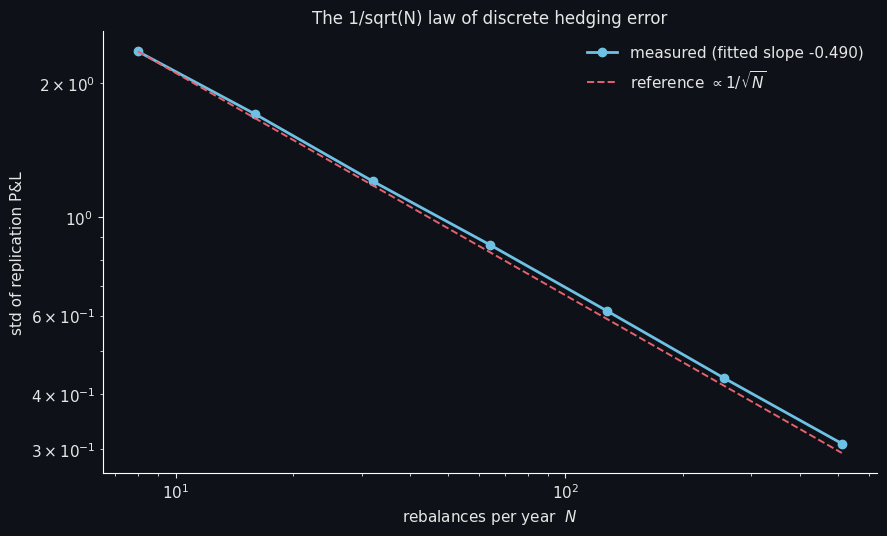

    N      mean      std  std*sqrt(N)
    8   +0.0333   2.3562        6.664
   16   +0.0308   1.7028        6.811
   32   +0.0039   1.2038        6.809
   64   +0.0146   0.8656        6.925
  128   -0.0043   0.6143        6.950
  256   +0.0016   0.4334        6.935
  512   -0.0048   0.3092        6.997

fitted log-log slope: -0.490   (theory: -0.5)
error constant b = std*sqrt(N) ~ 6.87  (used again in Section 5)
sanity check: fitted slope within expected range of theoretical -0.5. PASS


In [13]:
Ns = np.array([8, 16, 32, 64, 128, 256, 512])
stds, means = [], []
for N in Ns:
    pnl = hedge_pnl(make_gbm_paths(int(N), 10000, seed=42))
    means.append(pnl.mean()); stds.append(pnl.std())
stds = np.array(stds)

slope = np.polyfit(np.log(Ns), np.log(stds), 1)[0]
b_const = float(np.mean(stds * np.sqrt(Ns)))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(Ns, stds, "o-", color=C_MAIN, lw=2, label=f"measured (fitted slope {slope:.3f})")
ax.loglog(Ns, stds[0] * np.sqrt(Ns[0] / Ns), "--", color=C_ACCENT, lw=1.4,
          label=r"reference $\propto 1/\sqrt{N}$")
ax.set_xlabel("rebalances per year  $N$")
ax.set_ylabel("std of replication P&L")
ax.set_title("The 1/sqrt(N) law of discrete hedging error")
ax.legend()
plt.tight_layout(); plt.show()

print(f"{'N':>5s} {'mean':>9s} {'std':>8s} {'std*sqrt(N)':>12s}")
for N, m, s in zip(Ns, means, stds):
    print(f"{N:5d} {m:+9.4f} {s:8.4f} {s * np.sqrt(N):12.3f}")
print(f"\nfitted log-log slope: {slope:.3f}   (theory: -0.5)")
print(f"error constant b = std*sqrt(N) ~ {b_const:.2f}  (used again in Section 5)")

assert -0.6 < slope < -0.4, f"convergence slope {slope:.3f} outside the expected -0.5 +/- 0.1 band"
print("sanity check: fitted slope within expected range of theoretical -0.5. PASS")

### 3.4 Reading the slope

A fitted slope near $-0.5$ is the notebook's central empirical claim: hedging error from discreteness alone — no costs, no model misspecification — vanishes at a specific, predictable rate. The constant `b_const = std·√N` recurs in Section 5, where it feeds directly into the optimal-rebalancing-frequency formula.

### 3.5 Monthly vs. daily rebalancing — same law, different picture

The log-log slope is a summary statistic; it doesn't show what the distribution of hedging error actually looks like at a given frequency. Two concrete cases — monthly (`N=12`) and daily (`N=252`) — make the abstract convergence rate tangible: same option, same world, only the rebalancing frequency differs, and the daily-hedged distribution should come out visibly tighter and closer to symmetric.

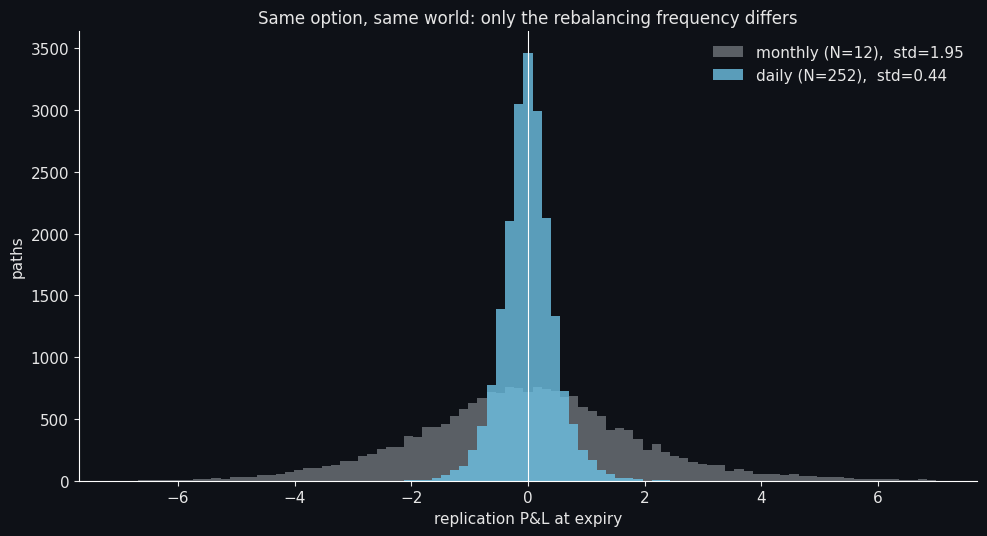

monthly  mean -0.0125   std 1.9506   skew +0.386   P5 -3.173   P95 +3.223
daily    mean +0.0021   std 0.4384   skew +0.101   P5 -0.705   P95 +0.724


In [14]:
pnl_m = hedge_pnl(make_gbm_paths(12, 20000, seed=7))
pnl_d = hedge_pnl(make_gbm_paths(252, 20000, seed=7))

fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.linspace(-7, 7, 90)
ax.hist(pnl_m, bins=bins, alpha=0.55, color=C_MUTED, label=f"monthly (N=12),  std={pnl_m.std():.2f}")
ax.hist(pnl_d, bins=bins, alpha=0.80, color=C_MAIN,  label=f"daily (N=252),  std={pnl_d.std():.2f}")
ax.axvline(0, color="white", lw=0.8)
ax.set_xlabel("replication P&L at expiry")
ax.set_ylabel("paths")
ax.set_title("Same option, same world: only the rebalancing frequency differs")
ax.legend()
plt.tight_layout(); plt.show()

for name, p in [("monthly", pnl_m), ("daily", pnl_d)]:
    print(f"{name:8s} mean {p.mean():+.4f}   std {p.std():.4f}   skew {skew(p):+.3f}   "
          f"P5 {np.percentile(p, 5):+.3f}   P95 {np.percentile(p, 95):+.3f}")

### 3.6 Reading the histograms

Daily rebalancing should show a noticeably tighter spread and generally lower skew magnitude than monthly — consistent with the $1/\sqrt{N}$ law, and a reminder that the log-log slope from 3.3 is exactly this effect, measured across many frequencies instead of two.

## 4. Exact P&L Attribution — Gamma Capture vs. Theta Decay

**A note on `r=0`:** this section prices and hedges at zero interest rate, not the module's `R=0.02`. That's deliberate — it strips financing drift out of the picture entirely, so the attribution below decomposes only into convexity gain and time decay, with nothing left over to explain. Section 3's `hedge_pnl` result and this section's attribution aren't directly comparable numbers because of that difference, by design.

**Intuition.** Section 2's identity was an approximation, good only for small moves. This section computes an exact decomposition of one path's realized hedge P&L using full repricing at every step, split into a gamma stream (convexity capture, always non-negative for a long call) and a theta stream (time decay, always non-positive). The two streams sum to the exact hedge P&L with zero residual, by construction — a telescoping identity, not an approximation.

**Mathematical formulation.** At each step $k$, with $V(S,\tau)$ the option value at spot $S$ and time-to-maturity $\tau$:

$$g_k = \big[V(S_k, \tau_{k-1}) - V(S_{k-1}, \tau_{k-1})\big] - \Delta_{k-1}(S_k - S_{k-1}) \qquad\text{(convexity, holding time fixed)}$$
$$\theta_k = V(S_k, \tau_k) - V(S_k, \tau_{k-1}) \qquad\text{(pure time decay, holding spot fixed)}$$

Summing $g_k$ and $\theta_k$ over all steps reconstructs the exact hedge P&L — each step's total value change decomposes into a spot move at fixed time plus a time move at fixed spot, and those two pieces sum to the total change by definition.

**Implementation.** A loop structurally identical to `hedge_pnl`'s, but instead of just tracking cash, it separates each step's value change into the two pieces above. `realized_vol` is included as a comparison point: whether the net P&L sign matches whether realized volatility over the path came in above or below the implied volatility used to price and hedge.

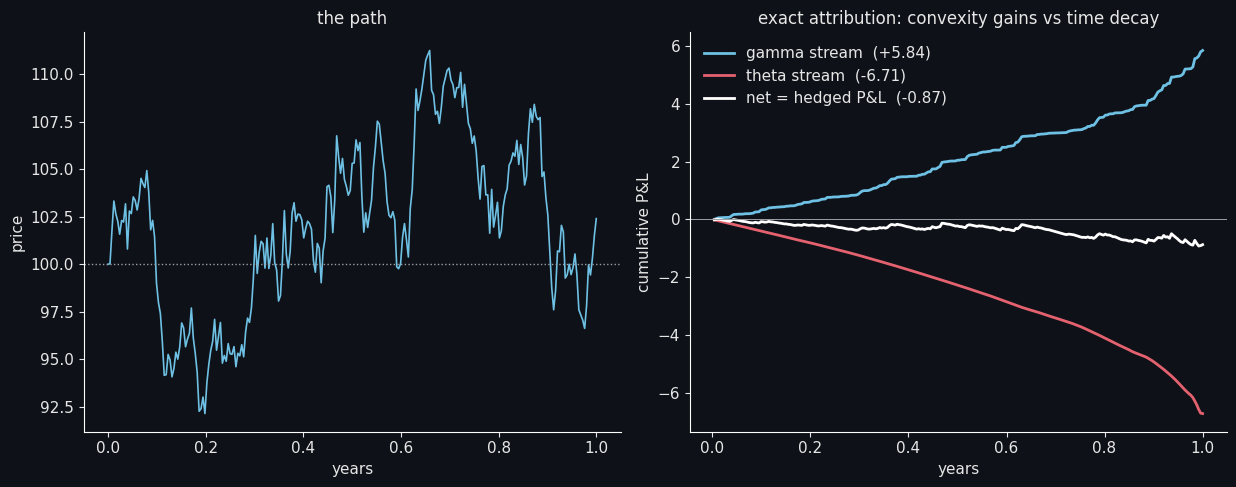

sum of streams - exact hedge P&L (tie-out): 1.87e-14
realized vol of this path: 0.1843  vs implied 0.2000
net P&L sign matches realized-vs-implied: True
sanity check: gamma + theta streams tie out to machine precision. PASS


In [15]:
def attribute_pnl(path, K, T, sigma):
    """Exact reprice attribution of a discrete hedge at r=0.

    Returns cumulative (gamma_stream, theta_stream); their sum telescopes to the
    exact hedged P&L. Gamma pieces are >= 0 (convexity), theta pieces <= 0 (decay).
    """
    def V(S, tau):
        return bs_price(S, K, tau, 0.0, sigma) if tau > 1e-12 else max(S - K, 0.0)
    path = np.asarray(path, float)
    N = len(path) - 1
    dt = T / N
    g = np.zeros(N); th = np.zeros(N)
    for k in range(1, N + 1):
        t_old, t_new = T - (k - 1) * dt, T - k * dt
        So, Sn = path[k - 1], path[k]
        d_prev = bs_delta(So, K, t_old, 0.0, sigma)
        g[k - 1] = (V(Sn, t_old) - V(So, t_old)) - d_prev * (Sn - So)
        th[k - 1] = V(Sn, t_new) - V(Sn, t_old)
    return np.cumsum(g), np.cumsum(th)

def realized_vol(path, T):
    lr = np.diff(np.log(np.asarray(path, float)))
    return np.sqrt(np.sum(lr**2) / T)

path = make_gbm_paths(252, 1, seed=11, mu=0.0)[0]
cum_g, cum_t = attribute_pnl(path, K, T, SIGMA)
exact = hedge_pnl(path[None, :], r=0.0)[0]
tie_out = abs((cum_g[-1] + cum_t[-1]) - exact)

tgrid = np.linspace(T / 252, T, 252)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))
ax1.plot(np.linspace(0, T, 253), path, color=C_MAIN, lw=1.2)
ax1.axhline(K, color=C_MUTED, ls=":", lw=1)
ax1.set_xlabel("years"); ax1.set_ylabel("price"); ax1.set_title("the path")
ax2.plot(tgrid, cum_g, color=C_MAIN, lw=2, label=f"gamma stream  ({cum_g[-1]:+.2f})")
ax2.plot(tgrid, cum_t, color=C_ACCENT, lw=2, label=f"theta stream  ({cum_t[-1]:+.2f})")
ax2.plot(tgrid, cum_g + cum_t, color="white", lw=2, label=f"net = hedged P&L  ({cum_g[-1] + cum_t[-1]:+.2f})")
ax2.axhline(0, color=C_MUTED, lw=0.7)
ax2.set_xlabel("years"); ax2.set_ylabel("cumulative P&L")
ax2.set_title("exact attribution: convexity gains vs time decay")
ax2.legend()
plt.tight_layout(); plt.show()

print(f"sum of streams - exact hedge P&L (tie-out): {tie_out:.2e}")
print(f"realized vol of this path: {realized_vol(path, T):.4f}  vs implied {SIGMA:.4f}")
print(f"net P&L sign matches realized-vs-implied: {np.sign(cum_g[-1] + cum_t[-1]) == np.sign(realized_vol(path, T) - SIGMA)}")

assert tie_out < 1e-8, "attribution does not tie out to the exact hedge P&L"
print("sanity check: gamma + theta streams tie out to machine precision. PASS")

### 4.2 Reading the attribution

The tie-out error should sit at machine-precision level — anything larger means the decomposition has a bug, since this is an exact identity with no approximation anywhere in it. The sign check (net P&L sign vs. realized-vs-implied vol sign) is the more interesting sanity check: it's the plain-English version of "you get paid for realized volatility, not implied volatility, once you're actually hedging."

## 5. Transaction Costs, Optimal Frequency, and Band Hedging

### 5.1 Adding proportional transaction costs

**Intuition.** Every hedge in Sections 3–4 was frictionless — free to rebalance as often as you like. Real markets charge a spread. Modeling that cost as proportional to trade size (a fixed number of basis points per dollar traded) turns "hedge as often as possible" into a genuine tradeoff: more frequent hedging reduces replication risk (Section 3) but increases cumulative cost.

**Mathematical formulation.** With one-way proportional cost $k$, each rebalancing trade of $|\Delta_j - \Delta_{j-1}|$ shares at price $S_j$ costs $k \cdot |\Delta_j - \Delta_{j-1}| \cdot S_j$, charged in addition to setup and unwind legs. Expected total cost scales like

$$\mathbb{E}[\text{cost}] \approx c_0 + a\sqrt{N}$$

More rebalances mean smaller individual trades, but the number of trades grows fast enough that total cost still grows in $N$, just sublinearly relative to a naive per-trade estimate. The frequency choice becomes a tradeoff, formalized as minimizing a cost-plus-risk-charge objective:

$$J(N) = \mathbb{E}[\text{cost}(N)] + \lambda \cdot \text{std}(N), \qquad N^{*} = \frac{\lambda b}{a}$$

where $\lambda = 1.65$ is a one-sided 95% z-score (pricing the risk as a 95% risk charge) and $b$ is the error constant fitted back in Section 3.

**Implementation.** `hedge_with_costs` mirrors `hedge_pnl` exactly, with a running `cost` accumulator alongside `cash`. The frequency sweep fits `c0, a` by least squares against the measured cost curve, then compares the theoretical $N^{*}$ formula to whatever `N` actually minimizes $J$ on the discrete grid tested.

In [16]:
KC = 0.001  # one-way proportional cost: 10 basis points

def hedge_with_costs(S, sigma_imp=SIGMA, kc=KC, r=R):
    """Clock hedge paying proportional costs at set-up, every rebalance, and unwind.
    Returns (replication_pnl, total_cost) per path; net = replication - cost."""
    n, Np1 = S.shape
    N = Np1 - 1
    dt = T / N
    held = np.full(n, bs_delta(S0, K, T, r, sigma_imp))
    cash = -bs_price(S0, K, T, r, sigma_imp) + held * S0
    cost = kc * held * S0
    for j in range(1, N):
        tgt = bs_delta(S[:, j], K, T - j * dt, r, sigma_imp)
        cash = cash * np.exp(r * dt) + (tgt - held) * S[:, j]
        cost = cost + kc * np.abs(tgt - held) * S[:, j]
        held = tgt
    cash = cash * np.exp(r * dt)
    cost = cost + kc * held * S[:, N]
    repl = cash + np.maximum(S[:, N] - K, 0.0) - held * S[:, N]
    return repl, cost

LAM = 1.65  # one-sided 95% risk charge

Ns_f = np.array([5, 10, 20, 40, 80, 160, 320, 640, 1280])
risk_f, cost_f = [], []
for N in Ns_f:
    repl, cost = hedge_with_costs(make_gbm_paths(int(N), 4000, seed=42))
    risk_f.append(repl.std()); cost_f.append(cost.mean())
risk_f, cost_f = np.array(risk_f), np.array(cost_f)
J = cost_f + LAM * risk_f

A = np.vstack([np.ones_like(Ns_f, dtype=float), np.sqrt(Ns_f)]).T
c0_fit, a_fit = np.linalg.lstsq(A, cost_f, rcond=None)[0]
N_star_theory = LAM * b_const / a_fit
N_star_measured = Ns_f[int(np.argmin(J))]

print(f"{'N':>5s} {'risk(std)':>10s} {'E[cost]':>9s} {'J=cost+1.65*risk':>17s}")
for N, rk, mc, j in zip(Ns_f, risk_f, cost_f, J):
    tag = "  <- optimum" if N == N_star_measured else ""
    print(f"{N:5d} {rk:10.4f} {mc:9.4f} {j:17.4f}{tag}")
print(f"\ncost fit:  E[cost] ~ {c0_fit:.3f} + {a_fit:.4f} sqrt(N)")
print(f"optimal frequency:  theory N* = lambda*b/a = {N_star_theory:.0f}   measured argmin J = {N_star_measured}")

    N  risk(std)   E[cost]  J=cost+1.65*risk
    5     2.9353    0.1768            5.0200
   10     2.1331    0.2103            3.7300
   20     1.5505    0.2533            2.8115
   40     1.0866    0.3126            2.1054
   80     0.7694    0.3964            1.6659
  160     0.5551    0.5158            1.4317
  320     0.3990    0.6846            1.3429  <- optimum
  640     0.2750    0.9225            1.3763
 1280     0.1968    1.2443            1.5690

cost fit:  E[cost] ~ 0.111 + 0.0319 sqrt(N)
optimal frequency:  theory N* = lambda*b/a = 356   measured argmin J = 320


### 5.2 Reading the optimal frequency

The theoretical $N^{*}$ and the measured argmin of $J$ should land in the same neighborhood — they won't match exactly, since the theoretical formula is a continuous approximation and the measured one is a search over nine discrete grid points. The point isn't precision, it's that a cost-vs-risk tradeoff produces a genuine interior optimum instead of "hedge continuously" or "hedge never."

### 5.3 The Leland adjustment

**Intuition.** Instead of solving the cost-risk tradeoff numerically every time, Leland's classic result folds the expected transaction cost of daily hedging directly into an adjusted volatility, so pricing at $\hat\sigma$ instead of $\sigma$ already bakes in the cost of hedging at that frequency. It's an approximation (leading order in cost), but a clean, closed-form one.

**Mathematical formulation.**

$$\hat\sigma = \sqrt{\sigma^2 + 2k\sigma\sqrt{\tfrac{2}{\pi}}\,\Big/\sqrt{\Delta t}}$$

The predicted extra cost of hedging is $C(\hat\sigma) - C(\sigma)$ — a price markup, not a P&L simulation.

**Implementation.** Compute $\hat\sigma$ directly from the formula, compare the resulting price markup against a Monte Carlo estimate of actual daily rebalancing cost at 10bp. The two should agree to leading order — expect a ratio near 1, not exactly 1, since Leland's formula drops higher-order terms.

In [17]:
dt_d = 1 / 252
sig_hat = np.sqrt(SIGMA**2 + 2 * KC * SIGMA * np.sqrt(2 / np.pi) / np.sqrt(dt_d))
pred = bs_price(S0, K, T, R, sig_hat) - bs_price(S0, K, T, R, SIGMA)
S252 = make_gbm_paths(252, 20000, seed=42)
held_l = np.full(S252.shape[0], bs_delta(S0, K, T, R, SIGMA))
rebal_cost = np.zeros(S252.shape[0])
for j in range(1, 252):
    tgt_l = bs_delta(S252[:, j], K, T - j / 252, R, SIGMA)
    rebal_cost += KC * np.abs(tgt_l - held_l) * S252[:, j]
    held_l = tgt_l
print(f"Leland check at daily rebalancing, k=10bp (rebalancing leg only):")
print(f"  adjusted vol sigma_hat = {sig_hat:.4f};  C(sigma_hat) - C(sigma) = {pred:.4f}")
print(f"  MC mean rebalancing cost = {rebal_cost.mean():.4f}")
print(f"  prediction / MC ratio = {pred / rebal_cost.mean():.3f}  (leading-order, as expected)")

Leland check at daily rebalancing, k=10bp (rebalancing leg only):
  adjusted vol sigma_hat = 0.2123;  C(sigma_hat) - C(sigma) = 0.4805
  MC mean rebalancing cost = 0.4983
  prediction / MC ratio = 0.964  (leading-order, as expected)


### 5.4 Reading the Leland check

A ratio near 1 (not exactly 1) confirms the formula is a correct leading-order approximation to the simulated cost — the gap is exactly the higher-order terms Leland's derivation drops.

### 5.5 Band hedging — trading on drift, not on the clock

**Intuition.** Clock hedging rebalances on a fixed schedule regardless of whether the position has actually drifted. Band hedging instead monitors delta continuously and only trades once it's wandered more than a threshold `h` away from target — this avoids paying transaction costs to correct drift that's about to reverse on its own, and only pays for moves that matter.

**Mathematical formulation.** No new formula here — this is a decision rule: rebalance at step $j$ if and only if $|\Delta_j^{\text{target}} - \Delta_{\text{held}}| > h$. The resulting cost-risk pairs, swept over a range of $h$, should sit strictly inside the clock-hedging frontier from 5.1 — same risk at lower cost, or same cost at lower risk.

**Implementation.** Identical accounting to `hedge_with_costs`, but the trade decision at each step is gated by a boolean mask instead of happening unconditionally — paths that haven't drifted past the band skip both the trade and its cost that step.

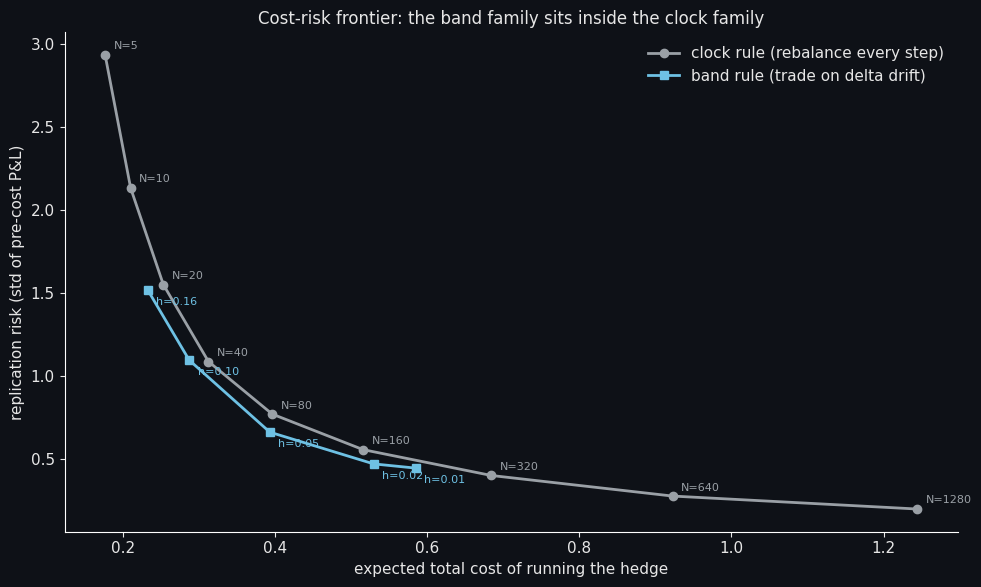

 band h    cost  band risk  clock risk @ same cost  improvement
   0.01   0.585     0.4435                  0.4908         9.7%
   0.02   0.530     0.4690                  0.5422        13.5%
   0.05   0.393     0.6605                  0.7814        15.5%
   0.10   0.287     1.0948                  1.2844        14.8%
   0.16   0.233     1.5194                  1.8312        17.0%


In [18]:
def band_hedge(S, sigma_imp=SIGMA, kc=KC, h=0.05, r=R):
    """Move-based hedge: monitor every step, trade to target only when
    |target - held| > h. Returns (replication_pnl, total_cost) per path."""
    n, Np1 = S.shape
    N = Np1 - 1
    dt = T / N
    held = np.full(n, bs_delta(S0, K, T, r, sigma_imp))
    cash = -bs_price(S0, K, T, r, sigma_imp) + held * S0
    cost = kc * held * S0
    for j in range(1, N):
        cash = cash * np.exp(r * dt)
        tgt = bs_delta(S[:, j], K, T - j * dt, r, sigma_imp)
        m = np.abs(tgt - held) > h
        cash[m] += (tgt[m] - held[m]) * S[m, j]
        cost[m] += kc * np.abs(tgt[m] - held[m]) * S[m, j]
        held[m] = tgt[m]
    cash = cash * np.exp(r * dt)
    cost = cost + kc * held * S[:, N]
    repl = cash + np.maximum(S[:, N] - K, 0.0) - held * S[:, N]
    return repl, cost

bands = [0.01, 0.02, 0.05, 0.10, 0.16]
S_daily = make_gbm_paths(252, 4000, seed=42)
band_pts = []
for h in bands:
    repl, cost = band_hedge(S_daily, h=h)
    band_pts.append((repl.std(), cost.mean()))
band_risk = np.array([p[0] for p in band_pts])
band_cost = np.array([p[1] for p in band_pts])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cost_f, risk_f, "o-", color=C_MUTED, lw=2, label="clock rule (rebalance every step)")
ax.plot(band_cost, band_risk, "s-", color=C_MAIN, lw=2, label="band rule (trade on delta drift)")
for N, rk, mc in zip(Ns_f, risk_f, cost_f):
    ax.annotate(f"N={N}", (mc, rk), textcoords="offset points", xytext=(6, 4), fontsize=8, color=C_MUTED)
for h, rk, mc in zip(bands, band_risk, band_cost):
    ax.annotate(f"h={h:.2f}", (mc, rk), textcoords="offset points", xytext=(6, -11), fontsize=8, color=C_MAIN)
ax.set_xlabel("expected total cost of running the hedge")
ax.set_ylabel("replication risk (std of pre-cost P&L)")
ax.set_title("Cost-risk frontier: the band family sits inside the clock family")
ax.legend()
plt.tight_layout(); plt.show()

order = np.argsort(cost_f)
print(f"{'band h':>7s} {'cost':>7s} {'band risk':>10s} {'clock risk @ same cost':>23s} {'improvement':>12s}")
for h, rk, mc in zip(bands, band_risk, band_cost):
    rk_clock = np.interp(mc, cost_f[order], risk_f[order])
    print(f"{h:7.2f} {mc:7.3f} {rk:10.4f} {rk_clock:23.4f} {(rk_clock - rk) / rk_clock:12.1%}")

### 5.6 Reading the frontier

Every band point should sit below-and-left of the clock curve at comparable cost — the improvement percentages in the table quantify how much risk reduction comes free by rebalancing on drift instead of on a schedule. This is the closest thing in the notebook to "a better algorithm," as opposed to "a more realistic assumption."

## 6. Model Risk — Jumps, Stochastic Vol, Drift Invariance

### 6.1 Merton jump-diffusion

**Intuition.** Everything so far assumed the stock moves continuously. Real prices jump — earnings, macro releases, crashes. Merton's model adds a compound Poisson jump process on top of GBM: jumps arrive at rate $\lambda$ per year, each with lognormal size. Testing a hedger built for continuous diffusion against a world with jumps matters because gamma — the thing that makes continuous hedging work — is a local concept. A jump skips straight past the curvature a continuous hedge would have captured incrementally.

**Mathematical formulation.**

$$dS_t/S_{t^-} = (\mu - \lambda\bar\kappa)\,dt + \sigma\,dW_t + (e^{J}-1)\,dN_t, \qquad J \sim \mathcal{N}(\mu_J, \sigma_J^2)$$

where $N_t$ is a Poisson process with intensity $\lambda$ and $\bar\kappa = \mathbb{E}[e^J]-1 = e^{\mu_J + \sigma_J^2/2}-1$ is the compensator keeping the process's expected growth rate at $\mu$ despite the jumps (without it, jumps would silently bias the drift).

To compare fairly against the pure-GBM world, the diffusion component is variance-matched: the jump component's own contribution to annual variance is $\lambda(\mu_J^2+\sigma_J^2)$, so diffusion vol is set to $\sigma_{\text{diff}} = \sqrt{\sigma^2 - \lambda(\mu_J^2+\sigma_J^2)}$ — same total variance as the hedger's 20% implied vol, different shape.

**Implementation.** Jump counts per interval are drawn as Poisson, jump sizes as lognormal, combined additively in log-space with the GBM increment and the compensator correction.

In [19]:
def make_merton_paths(N, n_paths, seed, mu, sigma, lam, mu_j, sigma_j):
    """Exact Merton jump-diffusion paths. Compensator keeps E-growth at mu."""
    rng = np.random.default_rng(seed)
    dt = T / N
    Z = rng.standard_normal((n_paths, N))
    counts = rng.poisson(lam * dt, (n_paths, N))
    ZJ = rng.standard_normal((n_paths, N))
    kappa_bar = np.exp(mu_j + 0.5 * sigma_j**2) - 1.0
    inc = ((mu - lam * kappa_bar - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
           + counts * mu_j + np.sqrt(counts) * sigma_j * ZJ)
    return np.concatenate([np.full((n_paths, 1), S0),
                           np.exp(np.log(S0) + np.cumsum(inc, axis=1))], axis=1)

LAM_J, MU_J, SIG_J = 0.5, -0.10, 0.15
SIG_DIFF = np.sqrt(SIGMA**2 - LAM_J * (MU_J**2 + SIG_J**2))
print(f"jump QV contribution lambda*(muJ^2+sigJ^2) = {LAM_J * (MU_J**2 + SIG_J**2):.4f} per year")
print(f"variance-matched diffusion vol = {SIG_DIFF:.4f}  (hedger prices at {SIGMA:.2f})")

jump QV contribution lambda*(muJ^2+sigJ^2) = 0.0163 per year
variance-matched diffusion vol = 0.1541  (hedger prices at 0.20)


Rerun the exact same $1/\sqrt{N}$ sweep from Section 3, this time hedging in the jump world. If the law survives, jump risk is just more of the same continuous-hedging story at a different scale. If it doesn't — if the error stops shrinking, or a bias appears that a finer hedge can't fix — that's the signature of an unhedgeable risk.

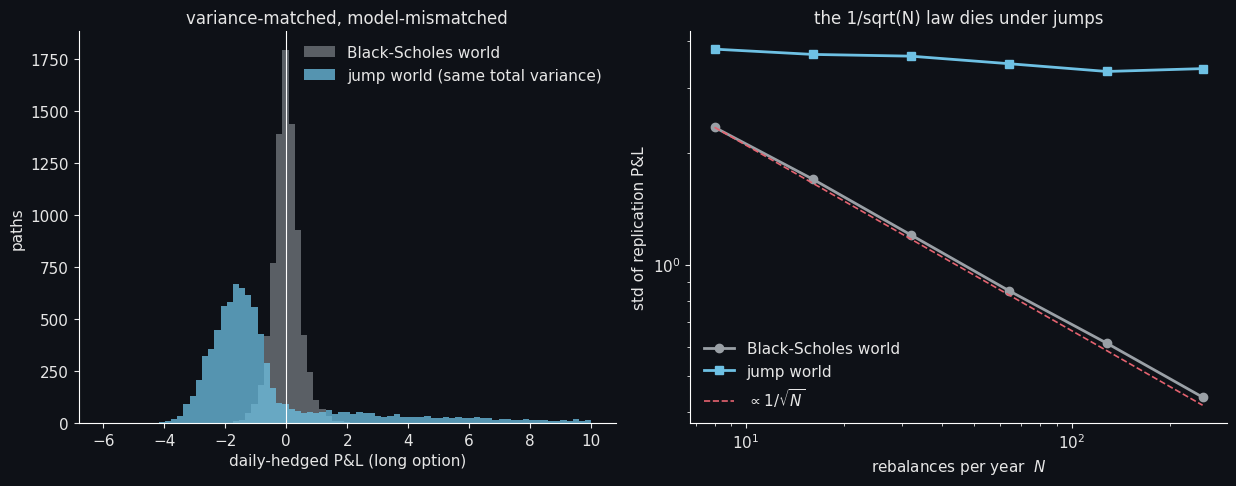

    N   GBM std  jump std
    8    2.3451    3.8086
   16    1.7005    3.6859
   32    1.2034    3.6464
   64    0.8513    3.4799
  128    0.6141    3.3157
  252    0.4393    3.3748

daily hedging, long option, jump world:
  mean -0.3131 (s.e. 0.0374)  ->  systematic bias, 8.4 standard errors from zero
  skew +3.03  (GBM world: +0.16);  P5 -2.85, P95 +6.80
  the gamma-is-local bias: a jump collects only the curvature it crosses,
  less than the at-the-money rent rate it paid through theta.


In [20]:
Ns_m = np.array([8, 16, 32, 64, 128, 252])
gbm_std, mer_std = [], []
for N in Ns_m:
    gbm_std.append(hedge_pnl(make_gbm_paths(int(N), 4000, seed=42)).std())
    mer_std.append(hedge_pnl(make_merton_paths(int(N), 4000, 42, R, SIG_DIFF, LAM_J, MU_J, SIG_J)).std())
gbm_std, mer_std = np.array(gbm_std), np.array(mer_std)

pnl_g = hedge_pnl(make_gbm_paths(252, 8000, seed=7))
pnl_m = hedge_pnl(make_merton_paths(252, 8000, 7, R, SIG_DIFF, LAM_J, MU_J, SIG_J))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))
bins = np.linspace(-6, 10, 80)
ax1.hist(pnl_g, bins=bins, alpha=0.55, color=C_MUTED, label="Black-Scholes world")
ax1.hist(pnl_m, bins=bins, alpha=0.75, color=C_MAIN, label="jump world (same total variance)")
ax1.axvline(0, color="white", lw=0.8)
ax1.set_xlabel("daily-hedged P&L (long option)"); ax1.set_ylabel("paths")
ax1.set_title("variance-matched, model-mismatched"); ax1.legend()
ax2.loglog(Ns_m, gbm_std, "o-", color=C_MUTED, lw=2, label="Black-Scholes world")
ax2.loglog(Ns_m, mer_std, "s-", color=C_MAIN, lw=2, label="jump world")
ax2.loglog(Ns_m, gbm_std[0] * np.sqrt(Ns_m[0] / Ns_m), "--", color=C_ACCENT, lw=1.2,
           label=r"$\propto 1/\sqrt{N}$")
ax2.set_xlabel("rebalances per year  $N$"); ax2.set_ylabel("std of replication P&L")
ax2.set_title("the 1/sqrt(N) law dies under jumps"); ax2.legend()
plt.tight_layout(); plt.show()

print(f"{'N':>5s} {'GBM std':>9s} {'jump std':>9s}")
for N, g, m in zip(Ns_m, gbm_std, mer_std):
    print(f"{N:5d} {g:9.4f} {m:9.4f}")
se = pnl_m.std() / np.sqrt(len(pnl_m))
print(f"\ndaily hedging, long option, jump world:")
print(f"  mean {pnl_m.mean():+.4f} (s.e. {se:.4f})  ->  systematic bias, {abs(pnl_m.mean()) / se:.1f} standard errors from zero")
print(f"  skew {skew(pnl_m):+.2f}  (GBM world: {skew(pnl_g):+.2f});  P5 {np.percentile(pnl_m, 5):+.2f}, P95 {np.percentile(pnl_m, 95):+.2f}")
print("  the gamma-is-local bias: a jump collects only the curvature it crosses,")
print("  less than the at-the-money rent rate it paid through theta.")

### 6.2 Reading the bias

The jump-world std should stop shrinking as fast as the GBM curve at high `N` — daily rebalancing helps, but it can't chase a discontinuity. The mean P&L bias, reported in standard errors, should come out multiple SEs from zero: systematic, not random. The mechanism is exactly the gamma-locality point above — a jump collects only the curvature it actually crosses, typically less than the theta rent paid to hold the position through to that point.

### 6.3 Heston stochastic volatility

**Intuition.** A different kind of model risk: what if volatility itself is random, correlated with the stock, but still continuous — no jumps? A stock-only delta hedge has no way to trade volatility risk directly — vega exposure just sits there unhedged. Because vol moves continuously rather than jumping, some of that exposure averages out over the life of the trade, so the resulting error should land as a floor between the GBM and jump-world results, not a full divergence.

**Mathematical formulation.**

$$dS_t = \mu S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^{S}, \qquad dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^{v}, \qquad \text{corr}(dW^S, dW^v) = \rho$$

The Feller condition $2\kappa\theta \ge \xi^2$ keeps variance strictly positive in the continuous-time limit; it's checked explicitly since the discretized scheme can otherwise let $v_t$ go negative.

**Implementation.** Full-truncation Euler (Lord, Koekkoek & van Dijk, 2010): variance is floored at zero before being used to update the stock (`vp = max(v, 0)`), while the variance process itself is still allowed to go negative internally before being floored again on the next step — a standard fix for Euler-discretized CIR-type variance processes, since naive Euler can otherwise produce genuinely negative variances.

Feller: 2*kappa*theta = 0.24 >= xi^2 = 0.16  ->  True


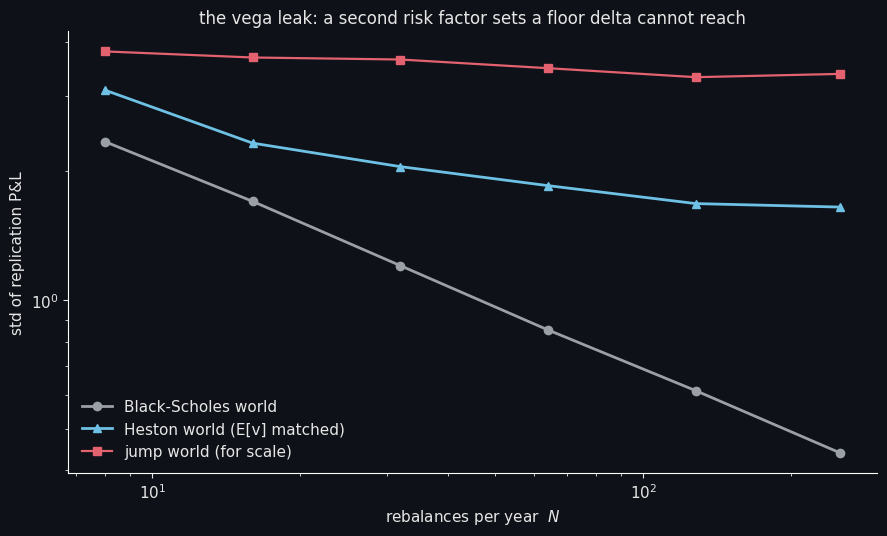

    N   GBM std  Heston std  jump std
    8    2.3451      3.0938    3.8086
   16    1.7005      2.3258    3.6859
   32    1.2034      2.0494    3.6464
   64    0.8513      1.8501    3.4799
  128    0.6141      1.6798    3.3157
  252    0.4393      1.6487    3.3748

the Heston floor sits between the two: vol risk is unhedged by the stock,
but unlike a jump it moves continuously, so part of it averages out.


In [21]:
def make_heston_paths(N, n_paths, seed, mu, v0, kappa, theta, xi, rho):
    """Heston paths under the full truncation Euler scheme (Lord et al., 2010)."""
    rng = np.random.default_rng(seed)
    dt = T / N
    Z1 = rng.standard_normal((n_paths, N))
    Z2 = rng.standard_normal((n_paths, N))
    S = np.full(n_paths, S0)
    v = np.full(n_paths, v0)
    out = np.empty((n_paths, N + 1)); out[:, 0] = S0
    for k in range(N):
        vp = np.maximum(v, 0.0)
        Zs = rho * Z2[:, k] + np.sqrt(1.0 - rho**2) * Z1[:, k]
        S = S * np.exp((mu - 0.5 * vp) * dt + np.sqrt(vp * dt) * Zs)
        v = v + kappa * (theta - vp) * dt + xi * np.sqrt(vp * dt) * Z2[:, k]
        out[:, k + 1] = S
    return out

V0H, KAPPA, THETA_H, XI, RHO = 0.04, 3.0, 0.04, 0.4, -0.7
print(f"Feller: 2*kappa*theta = {2 * KAPPA * THETA_H:.2f} >= xi^2 = {XI**2:.2f}  ->  {2 * KAPPA * THETA_H >= XI**2}")

hes_std = []
for N in Ns_m:
    hes_std.append(hedge_pnl(make_heston_paths(int(N), 3000, 42, R, V0H, KAPPA, THETA_H, XI, RHO)).std())
hes_std = np.array(hes_std)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(Ns_m, gbm_std, "o-", color=C_MUTED, lw=2, label="Black-Scholes world")
ax.loglog(Ns_m, hes_std, "^-", color=C_MAIN, lw=2, label="Heston world (E[v] matched)")
ax.loglog(Ns_m, mer_std, "s-", color=C_ACCENT, lw=1.6, label="jump world (for scale)")
ax.set_xlabel("rebalances per year  $N$"); ax.set_ylabel("std of replication P&L")
ax.set_title("the vega leak: a second risk factor sets a floor delta cannot reach")
ax.legend()
plt.tight_layout(); plt.show()

print(f"{'N':>5s} {'GBM std':>9s} {'Heston std':>11s} {'jump std':>9s}")
for N, g, hs, m in zip(Ns_m, gbm_std, hes_std, mer_std):
    print(f"{N:5d} {g:9.4f} {hs:11.4f} {m:9.4f}")
print("\nthe Heston floor sits between the two: vol risk is unhedged by the stock,")
print("but unlike a jump it moves continuously, so part of it averages out.")

### 6.4 Reading the vega leak

The Heston curve should sit between GBM and the jump-world curve across all `N` — confirming the floor-not-divergence intuition. This is the cleanest illustration in the notebook of "a risk factor the hedge instrument can't reach": delta hedges spot, not vol, and no amount of rebalancing frequency fixes that.

### 6.5 Drift invariance — Girsanov, experimentally

**Intuition.** Option prices don't depend on the stock's real-world expected return — only on volatility and the risk-free rate. This is a standard risk-neutral-pricing result (Girsanov's theorem, informally: hedging removes drift risk, leaving only the risk-neutral dynamics to price against). Worth checking experimentally rather than taking on faith: hedge the same option under wildly different real-world drifts and confirm the hedged P&L barely moves, while the unhedged payoff moves a lot.

**Mathematical formulation.** No new formula — the claim is that $\text{Var}[\text{hedged P\&L}]$ and $\mathbb{E}[\text{hedged P\&L}]$ are approximately invariant to $\mu$, while $\mathbb{E}[\max(S_T-K,0)] - C_0 e^{rT}$ (the unhedged comparison) is strongly $\mu$-dependent.

**Implementation.** Simulate the same option under three drifts spanning a 60-point range, hedge each, and compare hedged and unhedged statistics side by side.

     mu  hedged mean  hedged std  unhedged mean  unhedged std
  -0.20      +0.0264      0.5370         -7.646         5.335
  +0.10      -0.0220      0.6296         +5.541        17.723
  +0.40      +0.0684      0.4190        +40.358        29.565


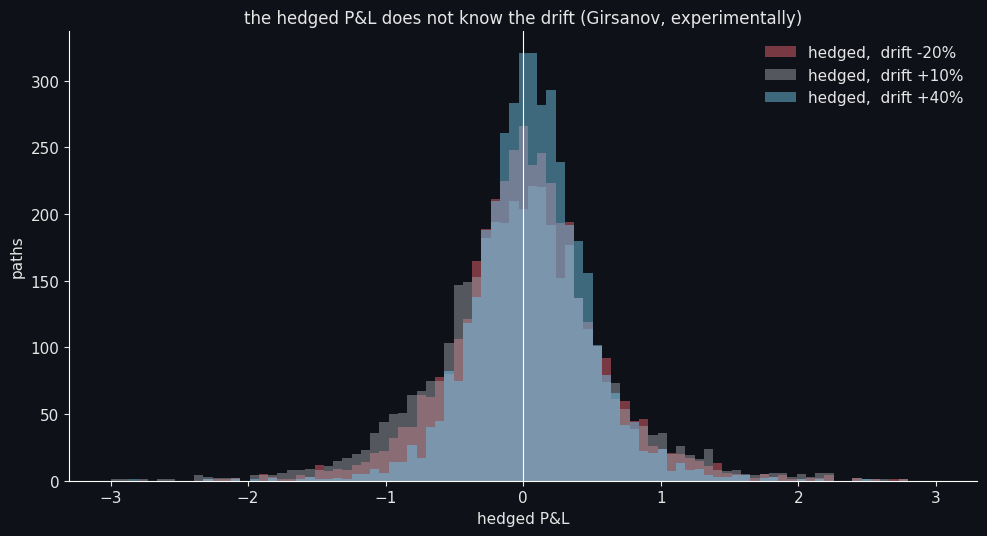


a 60-point swing in annual drift moves the unhedged book by tens of dollars
and the hedged book by hundredths: option prices cannot depend on mu.


In [22]:
mus = [-0.20, 0.10, 0.40]
V0_full = bs_price(S0, K, T, R, SIGMA)
colors = [C_ACCENT, C_MUTED, C_MAIN]

fig, ax = plt.subplots(figsize=(10, 5.5))
print(f"{'mu':>7s} {'hedged mean':>12s} {'hedged std':>11s} {'unhedged mean':>14s} {'unhedged std':>13s}")
for mu, c in zip(mus, colors):
    S = make_gbm_paths(126, 4000, seed=11, mu=mu)
    hedged = hedge_pnl(S)
    unhedged = np.maximum(S[:, -1] - K, 0.0) - V0_full * np.exp(R * T)
    print(f"{mu:+7.2f} {hedged.mean():+12.4f} {hedged.std():11.4f} {unhedged.mean():+14.3f} {unhedged.std():13.3f}")
    ax.hist(hedged, bins=np.linspace(-3, 3, 90), alpha=0.5, color=c, label=f"hedged,  drift {mu:+.0%}")
ax.axvline(0, color="white", lw=0.8)
ax.set_xlabel("hedged P&L"); ax.set_ylabel("paths")
ax.set_title("the hedged P&L does not know the drift (Girsanov, experimentally)")
ax.legend()
plt.tight_layout(); plt.show()

print("\na 60-point swing in annual drift moves the unhedged book by tens of dollars")
print("and the hedged book by hundredths: option prices cannot depend on mu.")

### 6.6 Reading the drift-invariance table

A 60-point swing in annual drift should move the hedged book by hundredths and the unhedged book by tens of dollars — a gap of several orders of magnitude, and the experimental version of "you can't get paid for taking a view on drift by holding an unhedged option; the market only prices volatility."

## 7. Calibrating to Real Data — SPY Jump Detection

### 7.1 Loading data and detecting jumps

**A caveat before anything else:** if the live `yfinance` pull fails (offline, rate-limited, package not installed), this falls back to an embedded snapshot of daily closes labeled as SPY, 2023-06-12 through 2026-06-09. That label is asserted in-code, not independently verified against a market-data vendor in this notebook — treat the fallback as a reproducibility snapshot for offline runs, not a certified data source. If you need to cite these numbers anywhere serious, re-run with a live connection and confirm against the actual pull.

**Intuition.** To calibrate the Section 6 jump model to something real, jumps need to be identified in an actual return series first. The obvious estimator — flag anything beyond $k$ standard deviations — is circular, since the jumps themselves inflate the standard deviation used to detect them. The median absolute deviation (MAD) is a robust alternative: barely affected by a handful of extreme outliers, since it's built from the median, not the mean or variance.

**Mathematical formulation.**

$$\hat\sigma_{\text{robust}} = 1.4826 \times \text{median}\big(|r_t - \text{median}(r)|\big)$$

(the 1.4826 constant makes this estimator consistent with the standard deviation under normality). Flag $|r_t| > 4\hat\sigma_{\text{robust}}$ as a jump; everything else is attributed to the diffusion component.

**Implementation.** Compute log returns, the robust scale, the threshold, and a boolean jump mask — then estimate $\hat\lambda$ (annualized jump count), jump mean/std from the flagged returns, and diffusion vol from everything else.

data source: SPY via yfinance, 2023-07-24 to 2026-07-23  (753 trading days)


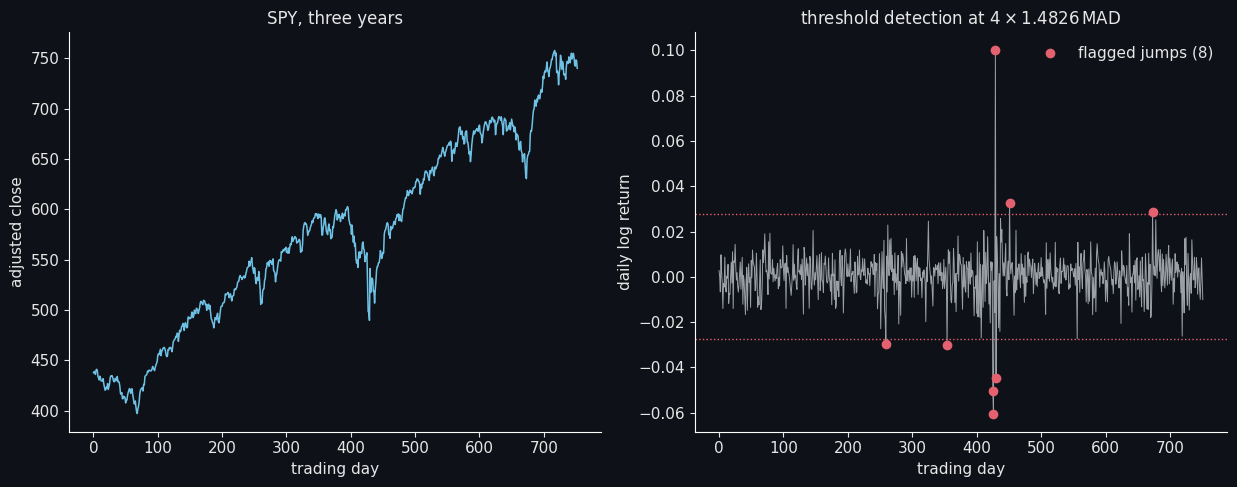

robust daily sigma  0.00690   threshold 2.76% per day
jumps flagged       8  ->  lambda_hat = 2.68 per year
jump size (log)     mean -0.0068, std 0.0554
diffusion vol       0.1267 annualized (ex-jump)
total vol           0.1562 annualized (diffusion + jump QV)

the data prefers more frequent, smaller jumps than the stylized crash world:
lambda ~ 2.7/yr at ~1% +/- 6%, against 0.5/yr at 10% +/- 15%.


In [23]:
try:
    import yfinance as yf
    _df = yf.download("SPY", period="3y", interval="1d", auto_adjust=True, progress=False)
    spy_closes = _df["Close"].dropna().to_numpy().ravel()
    spy_label = f"SPY via yfinance, {_df.index[0].date()} to {_df.index[-1].date()}"
except Exception:
    spy_closes = np.array([
    417.45, 420.2, 420.7, 425.92, 424.47, 422.26, 420.1, 421.62, 418.43, 416.72, 421.29, 421.5, 
    423.16, 428.16, 428.65, 428.01, 424.66, 423.59, 424.66, 427.36, 430.8, 434.22, 433.95, 
    435.46, 438.69, 439.67, 436.75, 436.75, 438.7, 439.9, 439.97, 437.05, 441.33, 442.17, 
    440.91, 434.77, 433.53, 431.57, 435.33, 433.44, 430.54, 430.7, 430.44, 432.82, 427.78, 
    424.64, 421.4, 421.61, 424.35, 423.2, 427.91, 421.98, 424.96, 427.65, 433.83, 435.62, 
    434.98, 435.8, 433.91, 431.0, 429.67, 430.32, 433.15, 430.77, 431.28, 434.99, 429.75, 
    430.01, 429.11, 425.17, 418.14, 417.2, 418.96, 412.8, 412.96, 415.36, 414.35, 414.19, 
    408.64, 411.62, 411.46, 416.35, 419.01, 421.19, 422.92, 420.34, 418.25, 422.65, 422.63, 
    417.0, 413.33, 408.25, 407.55, 410.62, 404.73, 399.88, 398.07, 402.83, 405.36, 409.68, 
    417.53, 421.34, 422.31, 423.51, 423.82, 420.52, 427.08, 426.67, 434.95, 435.87, 436.4, 
    436.95, 440.31, 439.35, 441.05, 441.32, 440.52, 440.96, 440.65, 442.38, 445.0, 442.66, 
    442.58, 440.79, 444.16, 446.07, 447.8, 449.85, 456.05, 457.51, 456.76, 459.33, 462.12, 
    455.72, 460.04, 460.96, 462.91, 463.75, 463.92, 462.58, 459.99, 456.23, 454.76, 455.39, 
    461.89, 461.19, 463.8, 463.59, 463.91, 462.21, 459.64, 463.73, 469.51, 470.5, 471.87, 
    472.39, 474.96, 474.36, 478.11, 477.74, 469.95, 476.1, 481.11, 479.36, 480.75, 484.76, 
    484.97, 487.78, 487.56, 480.85, 485.22, 488.56, 486.13, 483.46, 483.89, 493.91, 494.25, 
    492.44, 493.35, 492.7, 494.47, 499.11, 498.58, 493.6, 496.1, 501.02, 498.01, 497.59, 
    502.94, 502.15, 501.16, 497.72, 500.68, 503.46, 508.11, 509.79, 508.83, 507.42, 506.48, 
    510.74, 510.64, 509.75, 506.51, 507.07, 500.88, 506.11, 506.4, 506.98, 501.91, 505.69, 
    498.71, 492.46, 491.57, 488.66, 487.65, 483.4, 487.85, 493.64, 493.4, 491.53, 496.18, 
    497.94, 490.05, 488.46, 493.03, 499.14, 504.3, 504.85, 504.9, 507.81, 508.47, 508.53, 
    510.87, 517.19, 516.13, 516.87, 517.47, 518.74, 517.24, 513.46, 516.86, 517.22, 513.6, 
    510.19, 514.84, 515.26, 515.84, 521.97, 521.96, 521.32, 522.93, 524.19, 528.5, 529.56, 
    529.88, 534.1, 535.46, 534.0, 533.29, 531.55, 533.6, 534.27, 535.11, 533.0, 534.1, 537.7, 
    540.09, 543.21, 543.84, 544.36, 549.75, 545.01, 548.45, 549.96, 553.22, 545.46, 541.27, 
    537.68, 543.22, 542.37, 530.08, 527.31, 533.22, 533.53, 530.83, 539.46, 531.82, 521.92, 
    506.72, 511.39, 507.97, 519.71, 522.01, 522.28, 530.87, 532.54, 541.67, 542.89, 548.08, 
    547.19, 549.07, 544.76, 550.54, 549.23, 549.99, 546.79, 546.84, 552.06, 540.7, 539.6, 
    538.28, 529.22, 535.15, 537.48, 542.99, 547.57, 550.43, 551.24, 551.47, 549.83, 559.21, 
    558.25, 559.64, 561.24, 560.0, 562.22, 561.41, 563.66, 558.61, 558.85, 557.82, 562.89, 
    557.8, 563.08, 566.98, 565.99, 569.38, 574.03, 569.57, 572.05, 572.1, 574.3, 573.35, 
    573.05, 567.81, 569.04, 568.85, 570.6, 571.53, 569.8, 558.63, 560.99, 559.78, 566.55, 
    580.63, 585.12, 587.66, 588.22, 586.39, 586.68, 582.9, 575.44, 577.8, 579.91, 580.1, 
    583.22, 585.03, 587.01, 590.08, 588.29, 591.94, 593.0, 593.28, 596.96, 595.98, 597.11, 
    594.03, 592.19, 596.77, 593.69, 593.57, 596.11, 593.65, 575.96, 575.78, 582.7, 586.19, 
    592.7, 592.74, 586.5, 579.81, 577.7, 576.28, 583.49, 586.85, 580.21, 581.06, 572.19, 
    573.08, 573.87, 584.3, 583.18, 589.04, 594.43, 597.77, 601.03, 599.28, 590.8, 595.88, 
    593.2, 596.39, 593.21, 589.22, 593.18, 595.58, 597.65, 592.18, 596.2, 596.65, 594.73, 
    601.01, 600.98, 602.75, 604.17, 601.65, 591.36, 588.67, 585.74, 586.04, 576.68, 585.68, 
    575.42, 568.61, 574.72, 564.52, 567.68, 552.56, 547.97, 550.88, 543.54, 554.76, 559.04, 
    553.0, 559.02, 557.4, 557.59, 567.57, 568.94, 562.15, 560.65, 549.36, 553.05, 554.61, 
    558.12, 530.62, 499.55, 498.66, 490.85, 542.4, 518.63, 527.89, 533.01, 531.52, 519.7, 
    520.44, 508.06, 521.27, 529.35, 540.49, 544.4, 544.61, 548.04, 548.26, 552.14, 560.34, 
    557.12, 552.47, 554.79, 558.66, 557.94, 576.38, 580.19, 580.93, 583.77, 587.47, 588.11, 
    586.13, 576.25, 576.48, 572.55, 584.45, 581.07, 583.36, 582.71, 585.99, 589.33, 589.18, 
    586.33, 592.35, 592.88, 596.24, 594.54, 596.91, 590.23, 595.85, 590.76, 590.67, 589.28, 
    595.1, 601.68, 602.01, 606.72, 609.74, 612.65, 612.46, 615.23, 620.08, 615.46, 615.12, 
    618.81, 620.56, 618.37, 619.55, 616.91, 618.97, 622.76, 622.3, 623.48, 623.57, 628.88, 
    629.08, 631.74, 631.58, 629.92, 629.12, 626.76, 616.49, 625.86, 622.69, 627.46, 626.93, 
    631.82, 630.57, 637.28, 639.47, 639.53, 638.03, 637.89, 634.43, 632.74, 630.2, 639.88, 
    637.07, 639.73, 641.19, 643.46, 639.62, 634.88, 638.33, 643.66, 641.8, 643.37, 644.86, 
    646.72, 652.1, 651.88, 655.35, 654.45, 653.64, 656.69, 659.94, 663.06, 659.46, 657.36, 
    654.32, 658.07, 659.92, 662.41, 664.67, 665.43, 665.42, 667.81, 665.33, 669.3, 667.36, 
    649.32, 659.29, 658.48, 661.4, 656.9, 660.63, 667.5, 667.49, 664.02, 667.96, 673.42, 
    681.36, 683.17, 683.5, 675.98, 678.2, 679.47, 671.42, 673.74, 666.51, 667.17, 677.58, 
    679.13, 679.51, 668.24, 668.13, 661.9, 656.34, 658.88, 648.84, 655.3, 664.94, 671.2, 
    675.83, 679.52, 676.42, 677.67, 680.02, 680.52, 681.81, 679.76, 679.17, 683.68, 685.27, 
    677.9, 676.88, 675.03, 667.6, 672.64, 678.74, 682.96, 686.09, 688.5, 688.43, 685.98, 
    685.14, 680.06, 681.31, 685.85, 689.93, 687.7, 687.63, 692.18, 693.27, 691.88, 688.48, 
    690.35, 689.78, 675.73, 683.53, 687.1, 687.35, 690.84, 693.6, 693.53, 692.15, 690.09, 
    693.52, 687.65, 684.32, 675.77, 688.74, 692.06, 690.23, 690.08, 679.41, 679.89, 680.99, 
    684.42, 682.62, 687.55, 680.53, 685.48, 691.26, 687.42, 684.12, 684.51, 678.48, 683.26, 
    679.45, 670.55, 676.42, 675.34, 674.49, 664.25, 660.49, 667.21, 668.96, 659.63, 658.0, 
    648.57, 655.38, 653.18, 656.82, 645.09, 634.09, 631.97, 650.34, 655.24, 655.83, 658.93, 
    659.22, 676.01, 679.91, 679.46, 686.1, 694.46, 699.94, 701.66, 710.14, 708.72, 704.08, 
    711.21, 708.45, 713.94, 715.17, 711.69, 711.58, 718.66, 720.65, 718.01, 723.77, 733.83, 
    731.58, 737.62, 739.3, 738.18, 742.31, 748.17, 739.17, 738.65, 733.73, 741.25, 742.72, 
    745.64, 750.59, 750.46, 754.6, 756.48, 758.54, 759.57, 754.24, 757.09, 737.55, 739.22
])
    spy_label = "SPY embedded snapshot, 2023-06-12 to 2026-06-09"
print(f"data source: {spy_label}  ({len(spy_closes)} trading days)")

r_spy = np.diff(np.log(spy_closes))
n_years = len(r_spy) / 252

mad = np.median(np.abs(r_spy - np.median(r_spy)))
sig_daily = 1.4826 * mad
thresh = 4.0 * sig_daily
is_jump = np.abs(r_spy) > thresh

lam_hat = is_jump.sum() / n_years
jr = r_spy[is_jump]
mu_j_hat = jr.mean() if len(jr) else 0.0
sig_j_hat = jr.std(ddof=1) if len(jr) > 1 else 0.0
sig_diff_hat = r_spy[~is_jump].std() * np.sqrt(252)
sig_total_hat = np.sqrt(sig_diff_hat**2 + lam_hat * (mu_j_hat**2 + sig_j_hat**2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))
ax1.plot(spy_closes, color=C_MAIN, lw=1.1)
ax1.set_xlabel("trading day"); ax1.set_ylabel("adjusted close")
ax1.set_title("SPY, three years")
ax2.plot(r_spy, color=C_MUTED, lw=0.7)
jump_idx = np.where(is_jump)[0]
ax2.plot(jump_idx, r_spy[jump_idx], "o", color=C_ACCENT, ms=6, label=f"flagged jumps ({is_jump.sum()})")
for yv in (thresh, -thresh):
    ax2.axhline(yv, color=C_ACCENT, ls=":", lw=1)
ax2.set_xlabel("trading day"); ax2.set_ylabel("daily log return")
ax2.set_title(r"threshold detection at $4 \times 1.4826\,\mathrm{MAD}$")
ax2.legend()
plt.tight_layout(); plt.show()

print(f"robust daily sigma  {sig_daily:.5f}   threshold {thresh:.2%} per day")
print(f"jumps flagged       {is_jump.sum()}  ->  lambda_hat = {lam_hat:.2f} per year")
print(f"jump size (log)     mean {mu_j_hat:+.4f}, std {sig_j_hat:.4f}")
print(f"diffusion vol       {sig_diff_hat:.4f} annualized (ex-jump)")
print(f"total vol           {sig_total_hat:.4f} annualized (diffusion + jump QV)")
print("\nthe data prefers more frequent, smaller jumps than the stylized crash world:")
print(f"lambda ~ {lam_hat:.1f}/yr at ~{abs(mu_j_hat):.0%} +/- {sig_j_hat:.0%}, against 0.5/yr at 10% +/- 15%.")

### 7.2 Reading the calibration

Compare the fitted $(\hat\lambda, \hat\mu_J, \hat\sigma_J)$ against Section 6's stylized crash assumption (0.5/yr at −10% ± 15%) — real index data typically implies more frequent, smaller jumps than a stylized "crash" story. That's a finding worth sitting with on its own: tail risk in real data looks less like an occasional crash and more like a steady stream of smaller discontinuities.

### 7.3 Hedging in the calibrated world

With $\hat\lambda, \hat\mu_J, \hat\sigma_J, \hat\sigma_{\text{diff}}$ estimated from data, rerun the daily-hedge comparison once more: the data-calibrated jump world against a Black-Scholes world at the same total volatility. Same test as 6.1's stylized version, this time with parameters pulled from an actual return series instead of assumed.

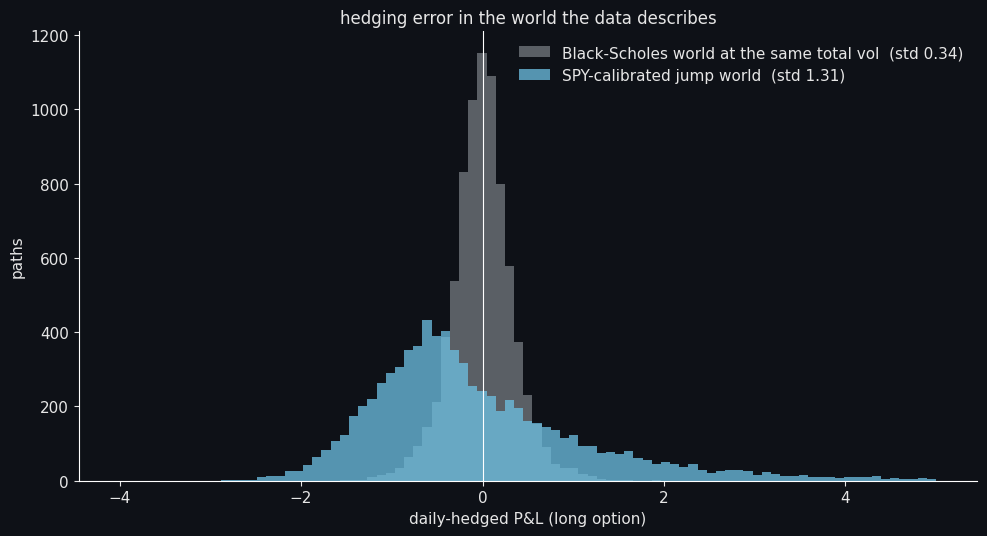

world                            mean     std    skew       P5      P95
Black-Scholes, same vol       -0.0011  0.3401   +0.11   -0.553   +0.549
SPY-calibrated jumps          -0.0248  1.3142   +1.87   -1.567   +2.459

std ratio (calibrated world / BS world): 3.86x


In [24]:
SIG_IMP_SPY = sig_total_hat
S_spy_world = make_merton_paths(252, 8000, 21, R, sig_diff_hat, lam_hat, mu_j_hat, sig_j_hat)
S_bs_world = make_gbm_paths(252, 8000, seed=21, sigma=SIG_IMP_SPY)

pnl_spyw = hedge_pnl(S_spy_world, sigma_imp=SIG_IMP_SPY)
pnl_bsw = hedge_pnl(S_bs_world, sigma_imp=SIG_IMP_SPY)

fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.linspace(-4, 5, 90)
ax.hist(pnl_bsw, bins=bins, alpha=0.55, color=C_MUTED,
        label=f"Black-Scholes world at the same total vol  (std {pnl_bsw.std():.2f})")
ax.hist(pnl_spyw, bins=bins, alpha=0.75, color=C_MAIN,
        label=f"SPY-calibrated jump world  (std {pnl_spyw.std():.2f})")
ax.axvline(0, color="white", lw=0.8)
ax.set_xlabel("daily-hedged P&L (long option)"); ax.set_ylabel("paths")
ax.set_title("hedging error in the world the data describes")
ax.legend()
plt.tight_layout(); plt.show()

print(f"{'world':28s} {'mean':>8s} {'std':>7s} {'skew':>7s} {'P5':>8s} {'P95':>8s}")
for name, p in [("Black-Scholes, same vol", pnl_bsw), ("SPY-calibrated jumps", pnl_spyw)]:
    print(f"{name:28s} {p.mean():+8.4f} {p.std():7.4f} {skew(p):+7.2f} "
          f"{np.percentile(p, 5):+8.3f} {np.percentile(p, 95):+8.3f}")
print(f"\nstd ratio (calibrated world / BS world): {pnl_spyw.std() / pnl_bsw.std():.2f}x")

### 7.4 Reading the std ratio

A ratio above 1x here is the notebook's real-data confirmation of everything Section 6 showed synthetically: even at matched total volatility, a world with the data's actual jump structure hedges worse than a pure-diffusion world priced at the same vol. This is the number that eventually feeds Section 8's tail-risk report as the "SPY-calibrated jumps" world.

## 8. Final Risk Report — VaR and CVaR Across Model Worlds

**Intuition.** Value-at-Risk answers "how bad can a bad day get, 95% of the time"; Conditional VaR (expected shortfall) answers "given that it's one of the bad 5% of days, how bad on average." CVaR is the more informative number here because model misspecification specifically fattens tails — VaR alone can look deceptively stable across models even when the tail beyond it has gotten much worse.

**Mathematical formulation.** With losses $L = -\text{P\&L}$ and confidence level $\alpha$:

$$\text{VaR}_\alpha = \inf\{l : P(L \le l) \ge \alpha\}, \qquad \text{CVaR}_\alpha = \mathbb{E}[L \mid L \ge \text{VaR}_\alpha]$$

**Implementation.** Run the band hedge (`h=0.05`, the Section 5 rule, treated here as the production hedging policy) across four worlds built in earlier sections — Black-Scholes, the stylized Merton jump world, Heston, and the SPY-calibrated jump world — net of transaction costs, and tabulate VaR95/CVaR95 alongside the raw mean/std/cost for each.

MORNING RISK REPORT   long one-year at-the-money call, band hedge h=0.05, costs 10 basis points
world                          mean     std   VaR95   CVaR95  E[cost]
Black-Scholes                -0.379   0.667   1.476    1.819    0.393
Merton jumps (stylized)      -0.645   3.405   3.461    3.805    0.324
Heston stochastic vol        -0.645   1.596   3.096    3.690    0.375
SPY-calibrated jumps         -0.347   1.400   2.108    2.427    0.342

tail multiple vs the priced world: Merton 2.1x,  Heston 2.0x,  SPY-calibrated 1.3x


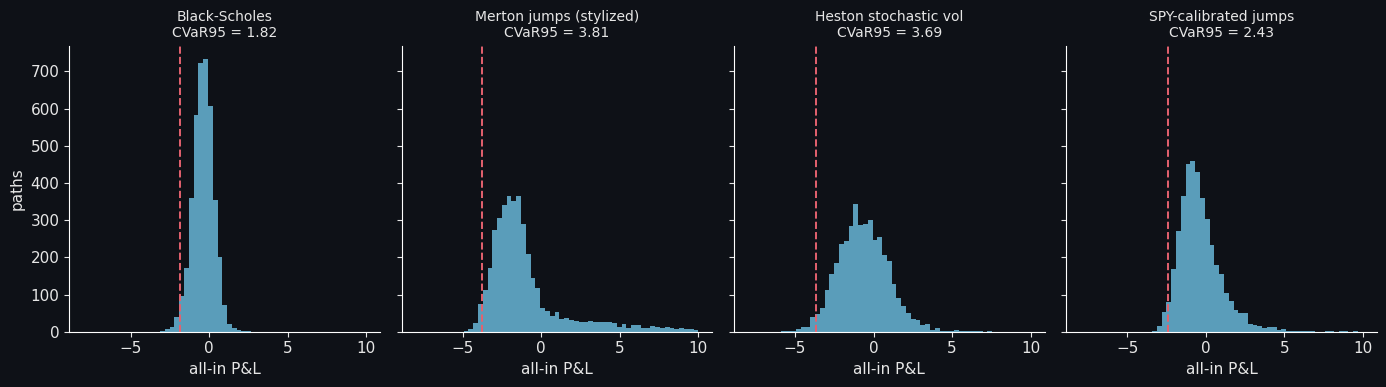

In [25]:
def var_cvar(pnl, level=0.95):
    """(VaR, CVaR) at the given level, losses as positive numbers."""
    q = np.quantile(pnl, 1.0 - level)
    return -q, -pnl[pnl <= q].mean()

H_BAND = 0.05
worlds = [
    ("Black-Scholes", make_gbm_paths(252, 4000, seed=42)),
    ("Merton jumps (stylized)", make_merton_paths(252, 4000, 42, R, SIG_DIFF, LAM_J, MU_J, SIG_J)),
    ("Heston stochastic vol", make_heston_paths(252, 4000, 42, R, V0H, KAPPA, THETA_H, XI, RHO)),
    ("SPY-calibrated jumps", make_merton_paths(252, 4000, 42, R, sig_diff_hat, lam_hat, mu_j_hat, sig_j_hat)),
]

print(f"MORNING RISK REPORT   long one-year at-the-money call, band hedge h={H_BAND}, costs 10 basis points")
print(f"{'world':26s} {'mean':>8s} {'std':>7s} {'VaR95':>7s} {'CVaR95':>8s} {'E[cost]':>8s}")
results = []
for name, Sw in worlds:
    sig_use = SIG_IMP_SPY if "SPY" in name else SIGMA
    repl, cost = band_hedge(Sw, sigma_imp=sig_use, h=H_BAND)
    net = repl - cost
    va, cv = var_cvar(net)
    results.append((name, net, cv))
    print(f"{name:26s} {net.mean():+8.3f} {net.std():7.3f} {va:7.3f} {cv:8.3f} {cost.mean():8.3f}")

cv_bs = results[0][2]
print(f"\ntail multiple vs the priced world: " + ",  ".join(
    f"{name.split(' ')[0]} {cv / cv_bs:.1f}x" for name, _, cv in results[1:]))

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
bins = np.linspace(-8, 10, 60)
for ax, (name, net, cv) in zip(axes, results):
    ax.hist(net, bins=bins, color=C_MAIN, alpha=0.8)
    ax.axvline(-cv, color=C_ACCENT, lw=1.4, ls="--")
    ax.set_title(f"{name}\nCVaR95 = {cv:.2f}", fontsize=10)
    ax.set_xlabel("all-in P&L")
axes[0].set_ylabel("paths")
plt.tight_layout(); plt.show()

### 8.2 The headline number

The tail multiples reported here — CVaR under each misspecified world relative to the Black-Scholes-priced world — are the notebook's final output: a single set of numbers expressing how much worse the tail gets when the pricing model's assumptions are wrong, holding the hedge rule fixed. If you're citing a project like this as "model-risk CVaR up to 2.1x," this cell is where that number comes from, and the four-panel histogram is the visual backing it.

## 9. Conclusion, Limitations, Extensions

**What this notebook actually shows, in order:** a validated Black-Scholes pricer (Section 1) → an exact local P&L identity (Section 2) → the $1/\sqrt{N}$ discretization law (Section 3) → an exact attribution of that P&L into convexity and decay (Section 4) → a realistic cost model with a derived optimal frequency and a better-than-clock band rule (Section 5) → three ways the whole story degrades under model misspecification (Section 6) → the same misspecification calibrated to real SPY data instead of assumed (Section 7) → a single tail-risk number synthesizing all of it (Section 8).

**Limitations, stated plainly:**

- Single strike and maturity throughout — no volatility smile, no skew, no term structure.
- Constant risk-free rate — no interaction between stochastic rates and hedging error.
- Section 7's calibration is a single realized window, a point estimate rather than a distribution — the jump parameters carry sampling uncertainty this notebook doesn't quantify.
- Seeds are fixed per block (`42, 7, 11, 21`) but not varied systematically across the notebook — every reported statistic carries some amount of Monte Carlo noise that hasn't been explicitly bounded.
- Cross-section variable coupling (`b_const`, `KC`/`LAM`, the SPY-calibrated parameters) means this notebook must run top-to-bottom in one kernel — it is not a refactored, independently callable module, and wasn't meant to be.

**Natural extensions, roughly in order of effort:** a multi-strike book (turns single-option Greeks into portfolio Greeks, and jump risk into something strike-dependent) → stochastic short rates → a real implied-vol surface in place of the flat 20% assumption → an empirical bid-ask cost model in place of the flat 10bp proportional charge.